In [1]:
!which pip

~/miniconda3/envs/autopath/bin/pip


In [2]:
from importlib import reload
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch

In [3]:
sys.path.insert(0, f"{os.environ['HOME']}/dinov2")

## ARCHITECTURE & WEIGHTS COMPARISON

### ssl

In [26]:
import autopath.gigaq.dinov2.train
reload(autopath.gigaq.dinov2.train)

<module 'autopath.gigaq.dinov2.train' from '/home/t-9dkarp/autopath/autopath/gigaq/dinov2/train.py'>

In [5]:
args = autopath.gigaq.dinov2.train.make_args()
args

Namespace(config_file=None, no_resume=False, eval_only=False, eval='', opts=[], output_dir=None)

In [6]:
cfg = autopath.gigaq.dinov2.train.make_cfg(args)
cfg

I20250623 22:42:24 2040836 dinov2 cfg.py:73] git:
  sha: e1277af2ba9496fbadf7aec6eba56e8d882d1e35, status: has uncommitted changes, branch: autoi/gigapath_uq

I20250623 22:42:24 2040836 dinov2 cfg.py:74] config_file: /home/t-9dkarp/autopath/autopath/gigapath_uq/dinov2/ssl.yaml
eval: 
eval_only: False
no_resume: False
opts: ['train.output_dir=/home/t-9dkarp/autopath/notebooks']
output_dir: /home/t-9dkarp/autopath/notebooks
I20250623 22:42:24 2040836 dinov2 cfg.py:33] sqrt scaling learning rate; base: 0.004, new: 0.001
I20250623 22:42:24 2040836 dinov2 cfg.py:40] MODEL:
  WEIGHTS: ''
compute_precision:
  grad_scaler: true
  teacher:
    backbone:
      sharding_strategy: SHARD_GRAD_OP
      mixed_precision:
        param_dtype: fp16
        reduce_dtype: fp16
        buffer_dtype: fp32
    dino_head:
      sharding_strategy: SHARD_GRAD_OP
      mixed_precision:
        param_dtype: fp16
        reduce_dtype: fp16
        buffer_dtype: fp32
    ibot_head:
      sharding_strategy: SHARD_GR

{'MODEL': {'WEIGHTS': ''}, 'compute_precision': {'grad_scaler': True, 'teacher': {'backbone': {'sharding_strategy': 'SHARD_GRAD_OP', 'mixed_precision': {'param_dtype': 'fp16', 'reduce_dtype': 'fp16', 'buffer_dtype': 'fp32'}}, 'dino_head': {'sharding_strategy': 'SHARD_GRAD_OP', 'mixed_precision': {'param_dtype': 'fp16', 'reduce_dtype': 'fp16', 'buffer_dtype': 'fp32'}}, 'ibot_head': {'sharding_strategy': 'SHARD_GRAD_OP', 'mixed_precision': {'param_dtype': 'fp16', 'reduce_dtype': 'fp16', 'buffer_dtype': 'fp32'}}}, 'student': {'backbone': {'sharding_strategy': 'SHARD_GRAD_OP', 'mixed_precision': {'param_dtype': 'fp16', 'reduce_dtype': 'fp16', 'buffer_dtype': 'fp32'}}, 'dino_head': {'sharding_strategy': 'SHARD_GRAD_OP', 'mixed_precision': {'param_dtype': 'fp16', 'reduce_dtype': 'fp32', 'buffer_dtype': 'fp32'}}, 'ibot_head': {'sharding_strategy': 'SHARD_GRAD_OP', 'mixed_precision': {'param_dtype': 'fp16', 'reduce_dtype': 'fp32', 'buffer_dtype': 'fp32'}}}}, 'dino': {'loss_weight': 1.0, 'head_

In [8]:
import autopath.gigaq.dinov2.ssl
reload(autopath.gigaq.dinov2.ssl)
ssl = autopath.gigaq.dinov2.ssl.SSL(cfg, device='cpu')

I20250623 22:43:30 2040836 dinov2 ssl.py:66] OPTIONS -- architecture : embed_dim: 1536
I20250623 22:43:30 2040836 dinov2 ssl.py:83] OPTIONS -- DINO
I20250623 22:43:30 2040836 dinov2 ssl.py:85] OPTIONS -- DINO -- loss_weight: 1.0
I20250623 22:43:30 2040836 dinov2 ssl.py:86] OPTIONS -- DINO -- head_n_prototypes: 65536
I20250623 22:43:30 2040836 dinov2 ssl.py:87] OPTIONS -- DINO -- head_bottleneck_dim: 256
I20250623 22:43:30 2040836 dinov2 ssl.py:88] OPTIONS -- DINO -- head_hidden_dim: 2048
I20250623 22:43:30 2040836 dinov2 ssl.py:100] OPTIONS -- DINO -- applying KOLEO regularization
I20250623 22:43:30 2040836 dinov2 ssl.py:110] OPTIONS -- IBOT
I20250623 22:43:30 2040836 dinov2 ssl.py:111] OPTIONS -- IBOT -- loss_weight: 1.0
I20250623 22:43:30 2040836 dinov2 ssl.py:112] OPTIONS -- IBOT masking -- ibot_mask_ratio_tuple: [0.1, 0.5]
I20250623 22:43:30 2040836 dinov2 ssl.py:113] OPTIONS -- IBOT masking -- ibot_mask_sample_probability: 0.5
I20250623 22:43:30 2040836 dinov2 ssl.py:136] OPTIONS 

In [9]:
tfe = ssl.teacher['backbone']
tfe

GigapathVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1536, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0): BlockChunk(
      (0-39): 40 x GigapathTensorBlock(
        (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1536, out_features=4608, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1536, out_features=1536, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
        (mlp): GluMlp(
          (fc1): Linear(in_features=1536, out_features=8192, bias=True)
          (act): SiLU()
          (drop1): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (fc

### dinov2

In [10]:
import autopath.gigaq.dinov2.features
reload(autopath.gigaq.dinov2.features)

<module 'autopath.gigapath_uq.dinov2.features' from '/home/t-9dkarp/autopath/autopath/gigapath_uq/dinov2/features.py'>

In [11]:
fe2, sb2, pp2 = autopath.gigaq.dinov2.features.gigapath_tile_feature_extractor_sideband_preprocessor(type='dinov2', device='cpu', load_state=True)

In [12]:
fe2.cls_token

Parameter containing:
tensor([[[ 0.0038,  0.0157,  0.0186,  ..., -0.0243,  0.0032,  0.0233]]],
       requires_grad=True)

In [13]:
fe2

GigapathVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1536, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0): BlockChunk(
      (0-39): 40 x GigapathTensorBlock(
        (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1536, out_features=4608, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1536, out_features=1536, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
        (mlp): GluMlp(
          (fc1): Linear(in_features=1536, out_features=8192, bias=True)
          (act): SiLU()
          (drop1): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (fc

In [14]:
fe2.blocks[0][0].ls1.gamma

Parameter containing:
tensor([ 0.0178, -0.0063, -0.0121,  ..., -0.0059, -0.0189, -0.0100],
       requires_grad=True)

In [15]:
fe2.blocks[0][0].ls1.gamma

Parameter containing:
tensor([ 0.0178, -0.0063, -0.0121,  ..., -0.0059, -0.0189, -0.0100],
       requires_grad=True)

In [16]:
fe2.blocks[0][0].attn.qkv.weight.shape

torch.Size([4608, 1536])

In [17]:
fe2.blocks[0][0].attn.qkv.weight.shape

torch.Size([4608, 1536])

### prov-gigapath

In [18]:
import slideflow as sf

In [19]:
import autopath.gigaq.dinov2.features
reload(autopath.gigaq.dinov2.features)

<module 'autopath.gigapath_uq.dinov2.features' from '/home/t-9dkarp/autopath/autopath/gigapath_uq/dinov2/features.py'>

In [20]:
fe, sb, pp = autopath.gigaq.dinov2.features.gigapath_tile_feature_extractor_sideband_preprocessor(type='prov-gigapath', device='cpu', load_state=True)

In [21]:
fe.cls_token

Parameter containing:
tensor([[[ 0.0038,  0.0157,  0.0186,  ..., -0.0243,  0.0032,  0.0233]]],
       requires_grad=True)

In [22]:
fe

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1536, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1536, out_features=4608, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1536, out_features=1536, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
      (mlp): GluMlp(
        (fc1): Linear(in_features=1536, out_features=8192, bias=True)
        (act): SiLU()
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
    

### weight comparison

In [23]:
def compare(f1, f2, *, verbose: bool = False):
    from autopath.gigaq.dinov2.features import model_blocks
    
    fe, fe2 = f1, f2
    display((f1.patch_embed.proj.weight == f2.patch_embed.proj.weight).all())
    if verbose:
        print(f"{f1.patch_embed.proj.weight=}")
        print(f"{f2.patch_embed.proj.weight=}")
    display((f1.patch_embed.proj.bias == f2.patch_embed.proj.bias).all())
    display(f2.patch_embed.norm)
    #
    b = 0
    blocks = model_blocks(fe)
    blocks2 = model_blocks(fe2)
    display((blocks[b].norm1.weight == blocks2[b].norm1.weight).all())
    display((blocks[b].norm1.bias == blocks2[b].norm1.bias).all())
    display((blocks[b].attn.qkv.weight == blocks2[b].attn.qkv.weight).all())
    display((blocks[b].attn.qkv.bias == blocks2[b].attn.qkv.bias).all())
    display((blocks[b].attn.proj.weight == blocks2[b].attn.proj.weight).all())
    display((blocks[b].attn.proj.bias == blocks2[b].attn.proj.bias).all())
    display((blocks[b].ls1.gamma == blocks2[b].ls1.gamma).all())
    display((blocks[b].norm2.weight == blocks2[b].norm2.weight).all())
    display((blocks[b].norm2.bias == blocks2[b].norm2.bias).all())
    display(type(blocks[b].mlp) == type(blocks2[b].mlp))
    mlp = blocks[b].mlp
    mlp2 = blocks2[b].mlp
    display(all([
       (mlp.gate_last == mlp2.gate_last),
    ]))
    display((blocks[b].mlp.fc1.weight == blocks2[b].mlp.fc1.weight).all())
    display((blocks[b].mlp.fc1.bias == blocks2[b].mlp.fc1.bias).all())
    display((blocks[b].mlp.fc2.weight == blocks2[b].mlp.fc2.weight).all())
    display((blocks[b].mlp.fc2.bias == blocks2[b].mlp.fc2.bias).all())
    display((blocks[b].ls2.gamma == blocks2[b].ls2.gamma).all())
    #
    display((fe.norm.bias == fe2.norm.bias).all())
    display((fe.norm.weight == fe2.norm.weight).all())
    #
    display((fe2.pos_embed == fe.pos_embed).all())

### teacher vs. dinov2:

In [25]:
compare(tfe, fe2)

tensor(True)

tensor(True)

Identity()

tensor(True)

tensor(True)

...

tensor(True)

tensor(True)

tensor(True)

tensor(True)

tensor(True)

### prov-gigapath vs. dinov2:

In [31]:
compare(fe, fe2)

tensor(True)

tensor(True)

Identity()

tensor(True)

tensor(True)

...

tensor(True)

tensor(True)

tensor(True)

tensor(True)

tensor(True)

In [29]:
%debug

> /home/t-9dkarp/miniconda3/envs/autopath/lib/python3.9/site-packages/torch/nn/modules/module.py(1614)__getattr__()
   1612             if name in modules:
   1613                 return modules[name]
-> 1614         raise AttributeError("'{}' object has no attribute '{}'".format(
   1615             type(self).__name__, name))
   1616 



ipdb>  up


> /tmp/ipykernel_1864317/1644092656.py(9)compare()
      7     b = 0
      8 
----> 9     display((fe.blocks[b].norm1.weight == fe2.blocks[0][b].norm1.weight).all())
     10     display((fe.blocks[b].norm1.bias == fe2.blocks[0][b].norm1.bias).all())
     11     display((fe.blocks[b].attn.qkv.weight == fe2.blocks[0][b].attn.qkv.weight).all())



ipdb>  fe.blocks[b]


BlockChunk(
  (0-39): 40 x GigapathTensorBlock(
    (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
    (attn): Attention(
      (qkv): Linear(in_features=1536, out_features=4608, bias=True)
      (q_norm): Identity()
      (k_norm): Identity()
      (attn_drop): Dropout(p=0.0, inplace=False)
      (proj): Linear(in_features=1536, out_features=1536, bias=True)
      (proj_drop): Dropout(p=0.0, inplace=False)
    )
    (ls1): LayerScale()
    (drop_path1): Identity()
    (norm2): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
    (mlp): GluMlp(
      (fc1): Linear(in_features=1536, out_features=8192, bias=True)
      (act): SiLU()
      (drop1): Dropout(p=0.0, inplace=False)
      (norm): Identity()
      (fc2): Linear(in_features=4096, out_features=1536, bias=True)
      (drop2): Dropout(p=0.0, inplace=False)
    )
    (ls2): LayerScale()
    (drop_path2): Identity()
  )
)


ipdb>  fe2.blocks[0][b]


GigapathTensorBlock(
  (norm1): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): Linear(in_features=1536, out_features=4608, bias=True)
    (q_norm): Identity()
    (k_norm): Identity()
    (attn_drop): Dropout(p=0.0, inplace=False)
    (proj): Linear(in_features=1536, out_features=1536, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): LayerScale()
  (drop_path1): Identity()
  (norm2): LayerNorm((1536,), eps=1e-06, elementwise_affine=True)
  (mlp): GluMlp(
    (fc1): Linear(in_features=1536, out_features=8192, bias=True)
    (act): SiLU()
    (drop1): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (fc2): Linear(in_features=4096, out_features=1536, bias=True)
    (drop2): Dropout(p=0.0, inplace=False)
  )
  (ls2): LayerScale()
  (drop_path2): Identity()
)


ipdb>  q


## OUTPUT COMPARISON

In [27]:
reload(autopath.gigaq.dinov2.features)
from autopath.gigaq.dinov2.features import model_blocks

In [28]:
L = len(model_blocks(fe))
num_heads = model_blocks(fe)[0].attn.num_heads
block_keys = ['norm1', 'attn_qkv', 'attn_proj', 'ls1', 'norm2', 'mlp_fc1', 'mlp_act', 'mlp_fc2', 'mlp_drop1', 'mlp', 'ls2',]

In [29]:
with open('gigapath/input.npz', 'rb') as f:
    inp = np.load(f)
    image = inp['image']
with open('gigapath/output.npz', 'rb') as f:
    out = np.load(f)
    output = out['output']
with open('gigapath/sideband.npz', 'rb') as f:
    sideb = np.load(f)
    bins = {l: {} for l in range(L)}
    bouts = {l: {} for l in range(L)}
    for l in range(L):
        for key in block_keys:
            bins[l][key] = sideb[f'B_{l}_{key}_input']
            bouts[l][key] = sideb[f'B_{l}_{key}']
    attention_maps = [sideb[f'attention_map_{L-1}_{h}'] for h in range(num_heads)]
    patch_embed = sideb['patch_embed']
    patch_embed_input = sideb['patch_embed_input']
    patch_embed_ = torch.tensor(patch_embed)
    pos_embed__ = fe._pos_embed(patch_embed_)
    pos_embed_ = pos_embed__.detach().numpy()
    model_norm_input = sideb['norm_input']
    model_norm = sideb['norm']
    model_head_input = sideb['head_input']
    model_head = sideb['head']
    model_input = sideb['model_input']
    model = sideb['model']
    bout0 = fe.blocks[0](fe.norm_pre(fe.patch_drop(pos_embed__))).detach().numpy()

In [30]:
with open('gigapath2/input.npz', 'rb') as f:
    inp2 = np.load(f)
    image2 = inp2['image']
with open('gigapath2/output.npz', 'rb') as f:
    out2 = np.load(f)
    output2 = out2['output']
with open('gigapath2/sideband.npz', 'rb') as f:
    sideb2 = np.load(f)
    attention_maps2 = [sideb2[f'attention_map_{L-1}_{h}'] for h in range(num_heads)]
    patch_embed2_input = sideb2['patch_embed_input']
    patch_embed2 = sideb2['patch_embed']
    patch_embed2_input_ = torch.tensor(sideb2['patch_embed_input'])
    pos_embed2 = fe2.prepare_tokens_with_masks(patch_embed2_input_).detach().numpy()
    patch_embed2_ = fe2.patch_embed(patch_embed2_input_)
    patch_embed2_ = torch.tensor(patch_embed2)
    pos_embed2_ = torch.cat((fe2.cls_token.expand(patch_embed2_.shape[0], -1, -1), patch_embed2_), dim=1)
    pos_embed2__ = (pos_embed2_ + fe2.pos_embed)
    pos_embed2_ = pos_embed2__.detach().numpy()
    bout02 = fe2.blocks[0](pos_embed2__).detach().numpy()
    bins2 = {l: {} for l in range(L)}
    bouts2 = {l: {} for l in range(L)}
    model_norm2_input = sideb2['norm_input']
    model_norm2 = sideb2['norm']
    model_head2_input = sideb2['head_input']
    model_head2 = sideb2['head']
    model2_input = sideb2['model_input']
    model2 = sideb2['model']
    for l in range(L):
        for key in block_keys:
            bins2[l][key] = sideb2[f'B_{l}_{key}_input']
            bouts2[l][key] = sideb2[f'B_{l}_{key}']

In [31]:
print(f"image: shape: {image.shape}, diff: {np.linalg.norm(image - image2)}")
print(f"patch_embed: input: shape: {patch_embed_input.shape}: diff: {np.linalg.norm(patch_embed_input - patch_embed2_input)}")
print(f"patch_embed: output: shape: {patch_embed.shape}: diff: {np.linalg.norm(patch_embed - patch_embed2)}")
print(f"pos_embed: shape: {pos_embed_.shape}: diff: {np.linalg.norm(pos_embed_ - pos_embed2_)}, norm: {np.linalg.norm(pos_embed_)}")
print(f"block[0]: shape: {bout0.shape}: diff: {np.linalg.norm(bout0 - bout02)}")
for key in ['model_norm', 'model_head', 'model']:
    val = locals()[key]
    val2 = locals()[f'{key}2']
    val_input = locals()[f'{key}_input']
    val2_input = locals()[f'{key}2_input']
    print(f"{key}: input: shape: {val_input.shape}: diff: {np.linalg.norm(val_input - val2_input)}")
    print(f"{key}: output: shape: {val.shape}: diff: {np.linalg.norm(val - val2)}")
for l in range(L):
    for k in block_keys:
        print(f"block[{l}].{k}: input: shape: {bins[l][k].shape}: diff: {np.linalg.norm(bins[l][k] - bins2[l][k])}")
        print(f"block[{l}].{k}: output: shape: {bouts[l][k].shape}: diff: {np.linalg.norm(bouts[l][k] - bouts2[l][k])}")
    print(f"-----------")

image: shape: (3, 256, 256), diff: 0.0
patch_embed: input: shape: (1, 3, 224, 224): diff: 0.0
patch_embed: output: shape: (1, 196, 1536): diff: 0.0
pos_embed: shape: (1, 197, 1536): diff: 0.0, norm: 700.3995361328125
block[0]: shape: (1, 197, 1536): diff: 2537.064697265625
model_norm: input: shape: (1, 197, 1536): diff: 0.0
model_norm: output: shape: (1, 197, 1536): diff: 0.0
model_head: input: shape: (1, 1536): diff: 0.0
model_head: output: shape: (1, 1536): diff: 0.0
model: input: shape: (1, 3, 224, 224): diff: 0.0
model: output: shape: (1, 1536): diff: 0.0
block[0].norm1: input: shape: (1, 197, 1536): diff: 0.0
block[0].norm1: output: shape: (1, 197, 1536): diff: 0.0
block[0].attn_qkv: input: shape: (1, 197, 1536): diff: 0.0
block[0].attn_qkv: output: shape: (1, 197, 4608): diff: 0.0
block[0].attn_proj: input: shape: (1, 197, 1536): diff: 0.0
block[0].attn_proj: output: shape: (1, 197, 1536): diff: 0.0
block[0].ls1: input: shape: (1, 197, 1536): diff: 0.0
block[0].ls1: output: shape

In [32]:
np.linalg.norm(output - output2)

0.0

# ATTENTIONS
### prov-gigapath & dinov2

In [33]:
with open('gigapath/input.npz', 'rb') as f:
    npz = np.load(f)
    image = npz['image']
with open('gigapath2/sideband.npz', 'rb') as f:
    npz2 = np.load(f)
    attention_maps2 = [npz2[f'attention_map_{L-1}_{h}'] for h in range(num_heads)]
    patch_embed2 = npz2['patch_embed']
with open('gigapath2/input.npz', 'rb') as f:
    npz2 = np.load(f)
    image2 = npz2['image']
with open('gigapath/sideband.npz', 'rb') as f:
    npz = np.load(f)
    attention_maps = [npz[f'attention_map_{L-1}_{h}'] for h in range(num_heads)]
    patch_embed = npz['patch_embed']

/tmp/ipykernel_1572373/3860648365.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(nrows=1, ncols=3)


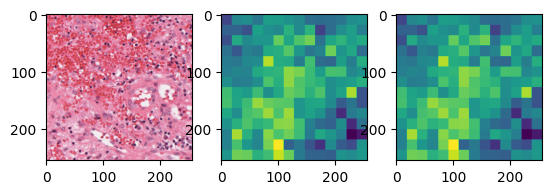

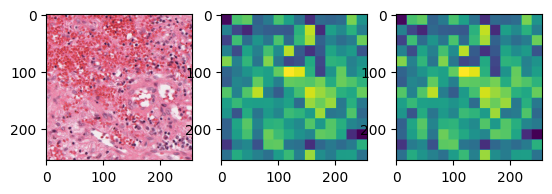

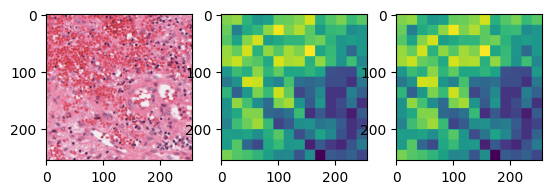

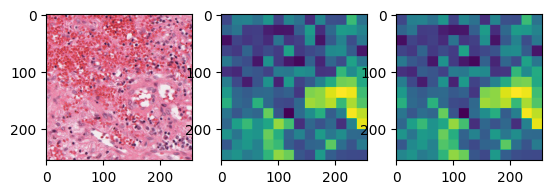

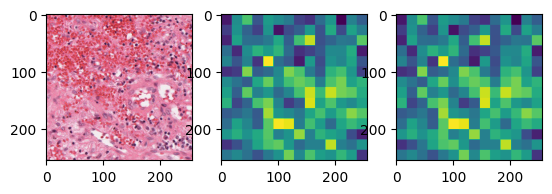

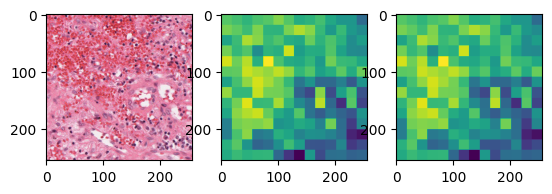

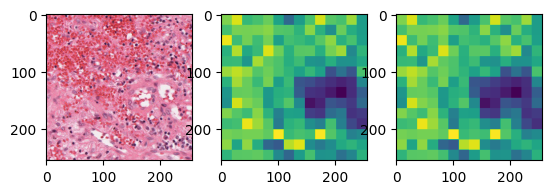

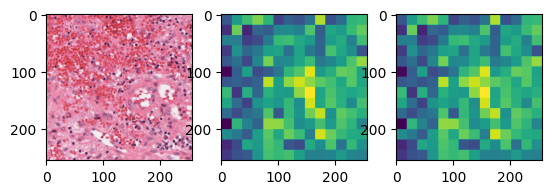

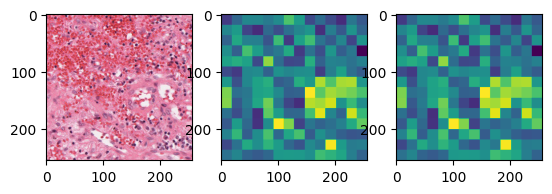

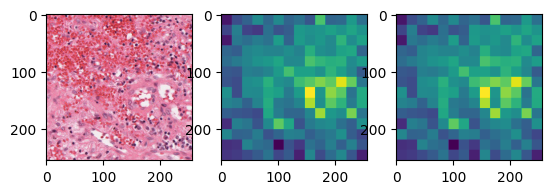

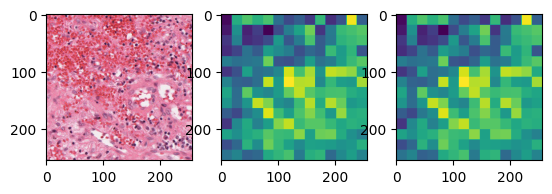

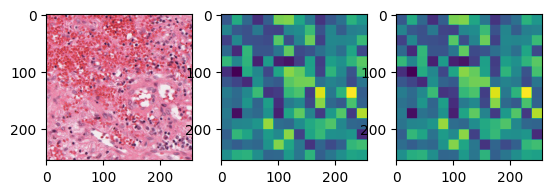

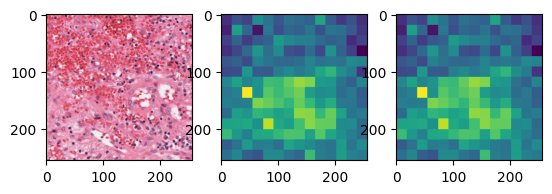

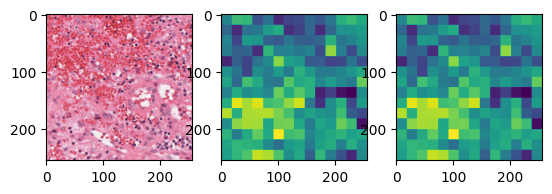

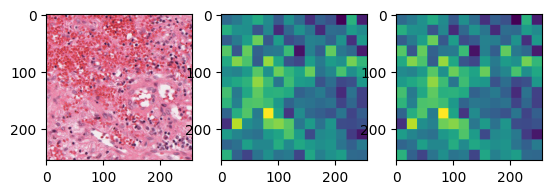

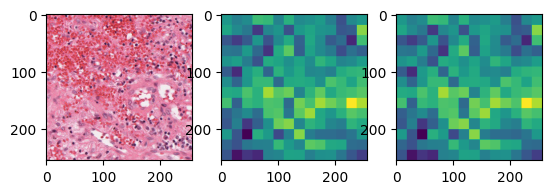

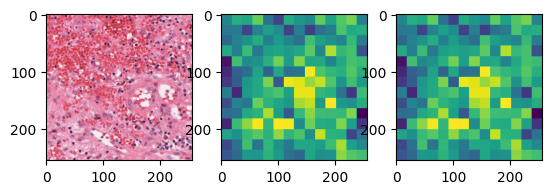

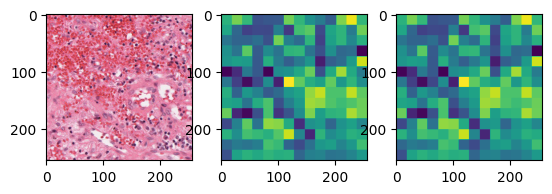

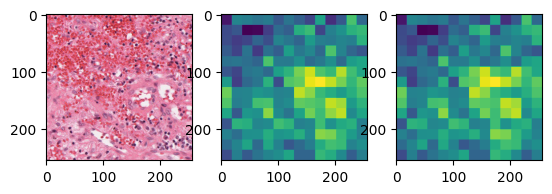

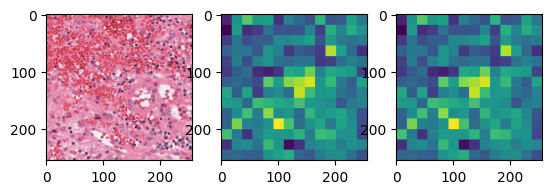

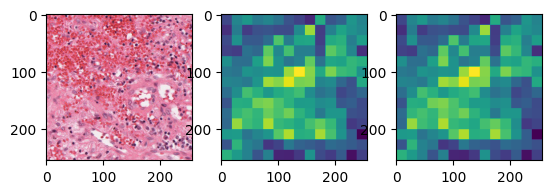

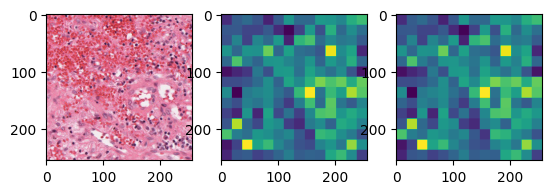

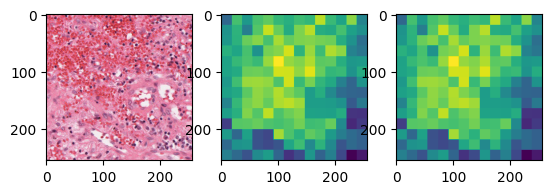

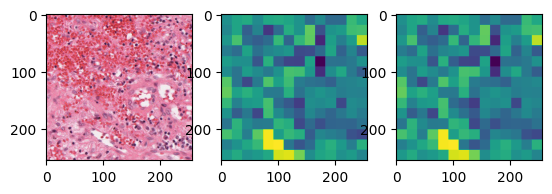

In [34]:
%matplotlib inline
L = len(model_blocks(fe))
num_heads = model_blocks(fe)[0].attn.num_heads
for h in range(num_heads):
    fig, axs = plt.subplots(nrows=1, ncols=3)
    axs[0].imshow(image.transpose(1, 2, 0))
    axs[1].imshow(attention_maps[h])
    #axs[0].imshow(image2.transpose(1, 2, 0))
    axs[2].imshow(attention_maps2[h])